Features:
*   Age | Objective Feature | age | int (days)
*   Height | Objective Feature | height | int (cm)
*   Weight | Objective Feature | weight | float (kg)
*   Gender | Objective Feature | gender | categorical code
*   Systolic blood pressure | Examination Feature | ap_hi | int
*   Diastolic blood pressure | Examination Feature | ap_lo | int
*   Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal
*   Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal
*   Smoking | Subjective Feature | smoke | binary
*   Alcohol intake | Subjective Feature | alco | binary
*   Physical activity | Subjective Feature | active | binary
*   Presence or absence of cardiovascular disease | Target Variable | cardio | binary



















In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('cardio_train.csv', sep=';')

# Konverzija iz godinama u danima u godine
data['age'] = data['age'] / 365.25

# Filtriranje prema realnim granicama
filtered = data[
    (data['height'] >= 120) & (data['height'] <= 220) &
    (data['weight'] >= 40) & (data['weight'] <= 200) &
    (data['ap_hi'] >= 80) & (data['ap_hi'] <= 250) &
    (data['ap_lo'] >= 40) & (data['ap_lo'] <= 200) &
    (data['ap_hi'] >= data['ap_lo'])
]
print(f"Broj redova pre: {len(data)}, posle: {len(filtered)}")

data = filtered
data = data.drop(columns="id")

# Dodajem kolonu BMI a izbacujem visinu i tezinu jer ih BMI kombinuje
data["bmi"] = data["weight"] / ((data["height"]/100)**2)
data = data.drop(columns=["weight", "height"])
cols = [
    "age",
    "gender",
    "bmi",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio",
]
data = data[cols]

data.info()



Broj redova pre: 70000, posle: 68570
<class 'pandas.core.frame.DataFrame'>
Index: 68570 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          68570 non-null  float64
 1   gender       68570 non-null  int64  
 2   bmi          68570 non-null  float64
 3   ap_hi        68570 non-null  int64  
 4   ap_lo        68570 non-null  int64  
 5   cholesterol  68570 non-null  int64  
 6   gluc         68570 non-null  int64  
 7   smoke        68570 non-null  int64  
 8   alco         68570 non-null  int64  
 9   active       68570 non-null  int64  
 10  cardio       68570 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 6.3 MB


0.505148023917165


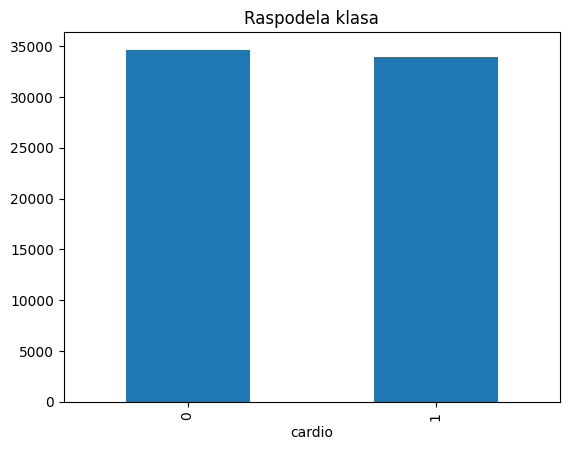

In [ ]:
klasa = data.cardio

p0 = sum(klasa == 0)/np.size(klasa) # 0.4467391304347826
p1 = sum(klasa == 1)/np.size(klasa) # 0.28804347826086957

print(p0)
klasa.value_counts().plot.bar(title='Raspodela klasa')
plt.show()

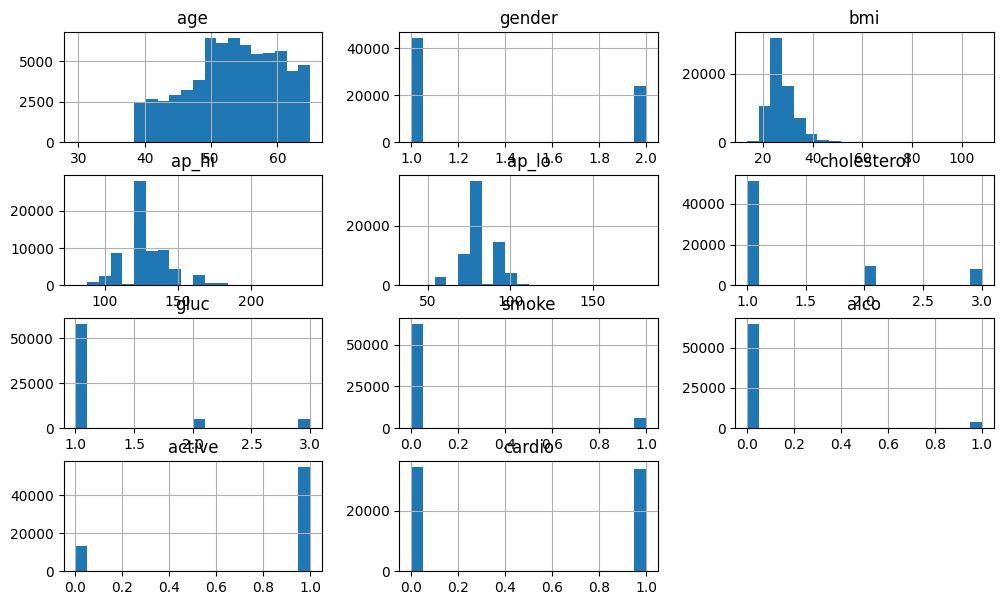

In [ ]:
data.hist(bins=20, figsize=(12,7))
plt.show()

In [ ]:
def calculateInfoD(col):
    un = np.unique(col)
    infoD = 0
    for u in un:
        p = sum(col == u)/len(col)
        infoD -= p*np.log2(p)
    return infoD

klasa = data.cardio
infoD = calculateInfoD(klasa)
IG = []
brojKoraka = 10
for ob in range(data.shape[1] - 1):
    kol = data.iloc[:, ob]
    f = np.unique(kol)

    if len(f) > brojKoraka:
        korak = (max(kol) - min(kol)) / brojKoraka
        kol = np.floor(kol / korak) * korak
        f = np.unique(kol)

    infoDA = 0
    for i in f:
        temp = klasa[kol == i]
        infoDi = calculateInfoD(temp)
        Di = sum(kol == i)
        D = len(kol)
        infoDA += Di * infoDi / D

    IG.append([data.columns[ob], infoD - infoDA])

IGdf = pd.DataFrame(IG, columns=['obelezje', 'IG'])
IGsorted = IGdf.sort_values(by=['IG'], ascending=False, ignore_index=True)
print(IGsorted)

      obelezje        IG
0        ap_hi  0.155387
1        ap_lo  0.102232
2          age  0.042331
3  cholesterol  0.036582
4          bmi  0.021273
5         gluc  0.006139
6       active  0.001024
7        smoke  0.000196
8         alco  0.000052
9       gender  0.000036


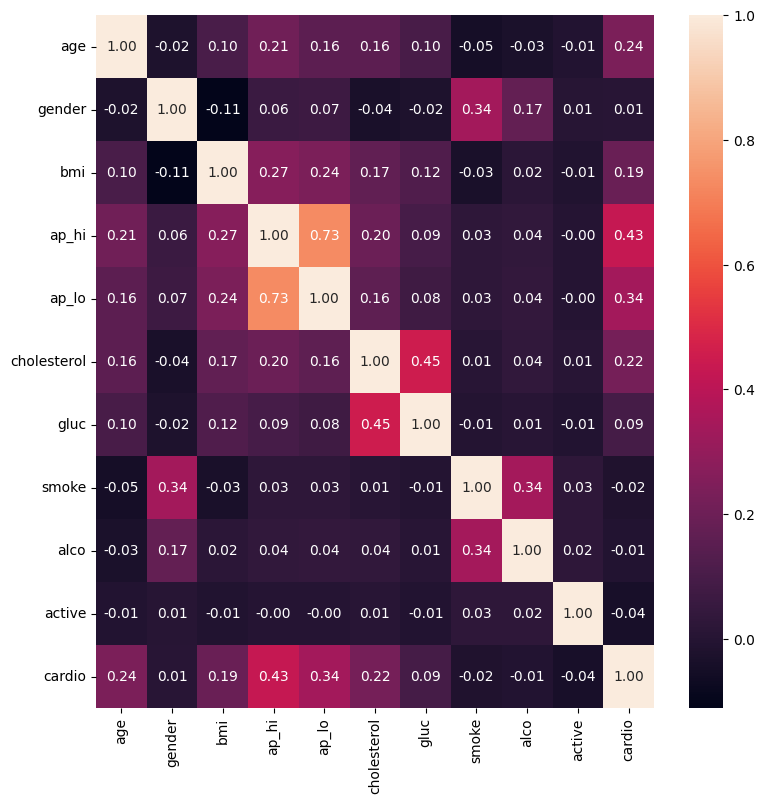

In [ ]:
# Pirsonovim koef korelacije
import seaborn as sns
pearson_R = data.corr(method='pearson')
plt.figure(figsize=(9, 9))
sns.heatmap(pearson_R, annot=True, fmt=".2f")
plt.yticks(rotation=0)
plt.show()

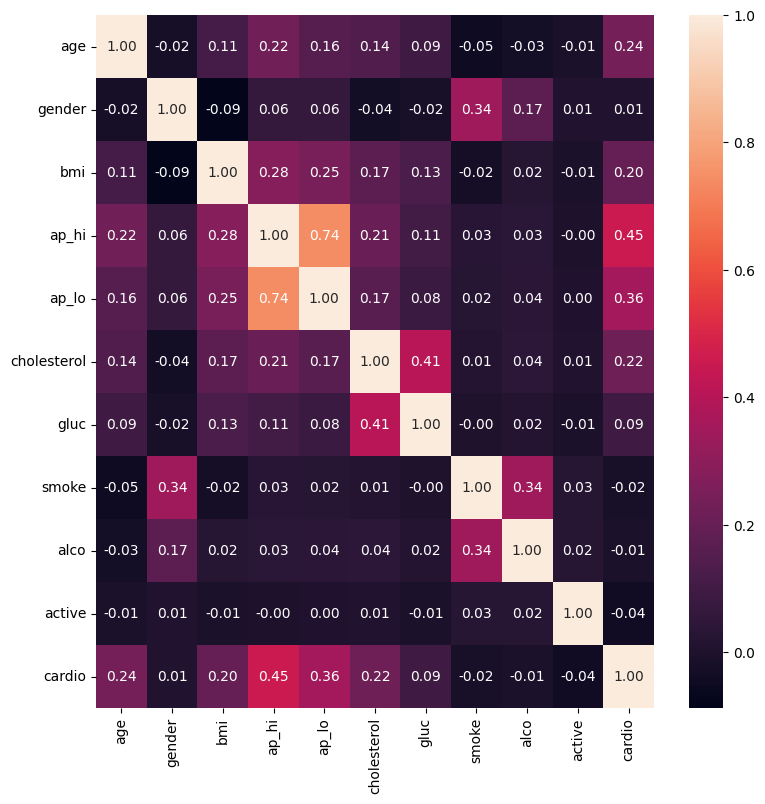

In [ ]:
# Spirmanovim koef korelacije
spearman_R = data.corr(method='spearman')
plt.figure(figsize=(9, 9))
sns.heatmap(spearman_R, annot=True, fmt=".2f")
plt.yticks(rotation=0)
plt.show()

In [ ]:
data = data.drop(columns = ["gender", "alco", "smoke"]) # najmanje informativna
X = pd.get_dummies(data.drop(columns=["cardio"]), columns=["cholesterol","gluc"], drop_first=True) # pretvara iz 1,2,3 u po 2 kolone sa 0,1 na odg mestima (obe 0 - 1.)
y = data["cardio"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train, shuffle=True)

# Standardizacija numeričkih kolona - prevođenje svakog CT numeričkog atributa na istu skalu tako da ima srednju vrednost 0 i std 1
from sklearn.preprocessing import StandardScaler
num_cols = ["age", "bmi", "ap_hi", "ap_lo"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
# fit izračuna srednju vrednost i standardnu devijaciju svake kolone u trening skupu
# transform koristi te vrednosti da transformiše i X_val i X_test

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log = LogisticRegression(max_iter=500)
log.fit(X_train, y_train)
y_pred = log.predict(X_test)
y_proba = log.predict_proba(X_test)[:,1]

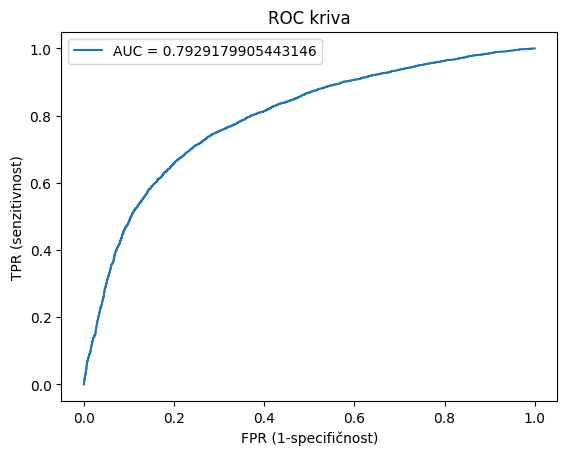

In [ ]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test,  y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)
plt.plot(fpr,tpr,label="AUC = " + str(auc))
plt.legend()
plt.title("ROC kriva")
plt.xlabel("FPR (1-specifičnost)")
plt.ylabel("TPR (senzitivnost)")
plt.show()

U ovom radu za evaluaciju klasifikatora koristićemo dve metode:
*   ROC krivu
*   konfuzionu matricu

ROC kriva (Receiver Operating Characteristic curve) prikazuje odnos između stope tačno pozitivnih detekcija (TPR) i stope lažno pozitivnih detekcija (FPR) za sve moguće pragove odluke. Omogućava vizuelnu procenu koliko dobro model razdvaja klase nezavisno od konkretnog praga.
AUC (Area Under the Curve) predstavlja površinu ispod ROC krive i meri ukupnu sposobnost modela da razlikuje pozitivne i negativne primere. Vrednost AUC = 0.5 označava nasumičnu klasifikaciju, dok vrednost bliža 1 označava bolje razdvajanje klasa.

Konfuziona matrica prikazuje rezultate klasifikacije pri izabranom pragu odluke. Sastoji se od broja tačno pozitivnih (TP), lažno pozitivnih (FP), tačno negativnih (TN) i lažno negativnih (FN) slučajeva. Iz nje se izračunavaju ključne metrike: tačnost, senzitivnost (TPR), specifičnost (TNR), preciznost i stopa lažno negativnih (FNR). Konfuziona matrica daje konkretnu sliku performansi modela i omogućava izbor praga koji najbolje odgovara kliničkom cilju - u ovom slučaju smanjenju broja propuštenih detekcija bolesti.

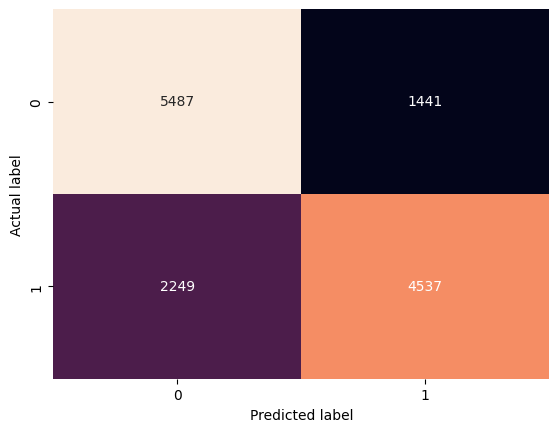

Tačnost klasifikacije iznosi 73.09%
Preciznost klasifikacije iznosi 75.89%
Senzitivnost klasifikacije iznosi 66.86%
Specifičnost klasifikacije iznosi 79.20%
Stopa lažno negativnih iznosti 33.14%


In [ ]:
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tačnost klasifikacije iznosi {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosi {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosi {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specifičnost klasifikacije iznosi {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

Dobili smo klasifikator zadovoljavajuće tačnosti, ali po cenu prevelikog broja propuštenih detekcija. Pošto je ključno smanjiti propuštene detekcije (FN), umesto fiksnog praga 0.5 optimizovaćemo operativni prag na validacionom skupu. Za niz pragova izračunaćemo metrike i izabrati onaj koji obezbeđuje FNR ≤ 15%, uz maksimalnu tačnost. Snižavanjem praga povećava se senzitivnost (TPR) i smanjuje FNR, po cenu većeg broja lažno pozitivnih (pad specifičnosti), što je u skladu sa kliničkim prioritetom da se bolest ne propusti.

In [ ]:
y_proba_val = log.predict_proba(X_val)[:,1]
thresholds = np.arange(0.1, 0.5, 0.01)
best = []
for th in thresholds:
    y_pred_th = (y_proba_val >= th).astype(int)
    cm = confusion_matrix(y_val, y_pred_th)
    TN, FP, FN, TP = cm.ravel()
    fnr = FN / (FN + TP)
    tpr = TP / (TP + FN)
    acc = (TP + TN) / cm.sum()
    best.append((th, fnr, acc))

for th, fnr, acc in best:
    if fnr <= 0.15 and acc >= 0.6:
        print(f"th={th:.2f}  FNR={fnr:.2f}  acc={acc:.2f}")

th=0.25  FNR=0.05  acc=0.61
th=0.26  FNR=0.05  acc=0.62
th=0.27  FNR=0.06  acc=0.62
th=0.28  FNR=0.07  acc=0.63
th=0.29  FNR=0.08  acc=0.64
th=0.30  FNR=0.09  acc=0.65
th=0.31  FNR=0.09  acc=0.65
th=0.32  FNR=0.10  acc=0.66
th=0.33  FNR=0.11  acc=0.67
th=0.34  FNR=0.12  acc=0.68
th=0.35  FNR=0.13  acc=0.69
th=0.36  FNR=0.15  acc=0.69


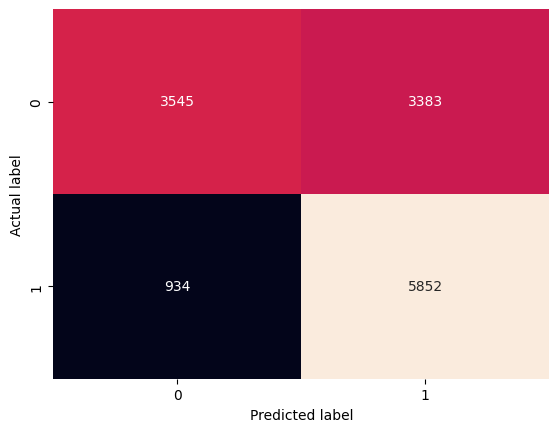

Tačnost klasifikacije iznosi 68.52%
Preciznost klasifikacije iznosi 63.37%
Senzitivnost klasifikacije iznosi 86.24%
Specifičnost klasifikacije iznosi 51.17%
Stopa lažno negativnih iznosti 13.76%


In [ ]:
# evaluacija klasifikatora pri novoizabranom pragu
best_th = 0.35
y_pred_th = (y_proba >= best_th).astype(int)

conf_mat = confusion_matrix(y_test, y_pred_th)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tačnost klasifikacije iznosi {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosi {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosi {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specifičnost klasifikacije iznosi {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

Pokazalo se da spuštanjem praga sa 0.5 na 0.35, može da se smanji stopa propuštenih detekcija sa 33% na približno 14%, uz očekivani pad ukupne tačnosti sa 73% na oko 69%.

Isti efekat može se postići povećavanjem parametra class_weight tokom učenja, čime model automatski favorizuje pozitivnu klasu. Ponderisanje klasa u odnosu 1:2 dalo je gotovo iste rezultate kao i ručno pomeranje praga na 0.35.

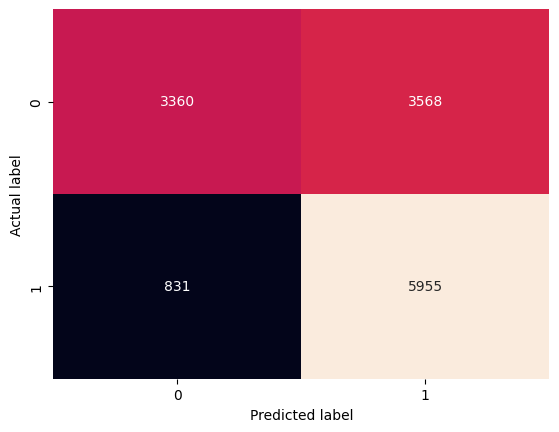

Tačnost klasifikacije iznosi 67.92%
Preciznost klasifikacije iznosi 62.53%
Senzitivnost klasifikacije iznosi 87.75%
Specifičnost klasifikacije iznosi 48.50%
Stopa lažno negativnih iznosti 12.25%


In [ ]:
log = LogisticRegression(max_iter=1000, class_weight={0:1,1:2})
log.fit(X_train, y_train)
y_pred = log.predict(X_test)
y_proba = log.predict_proba(X_test)[:,1]

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tačnost klasifikacije iznosi {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosi {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosi {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specifičnost klasifikacije iznosi {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')


In [ ]:
y_proba_val = log.predict_proba(X_val)[:,1]
thresholds = np.arange(0.1, 0.6, 0.01)
best = []
for th in thresholds:
    y_pred_th = (y_proba_val >= th).astype(int)
    cm = confusion_matrix(y_val, y_pred_th)
    TN, FP, FN, TP = cm.ravel()
    fnr = FN / (FN + TP)
    tpr = TP / (TP + FN)
    acc = (TP + TN) / cm.sum()
    best.append((th, fnr, acc))

for th, fnr, acc in best:
    if fnr <= 0.15 and acc >= 0.6:
        print(f"th={th:.2f}  FNR={fnr:.2f}  acc={acc:.2f}")

th=0.38  FNR=0.05  acc=0.60
th=0.39  FNR=0.05  acc=0.61
th=0.40  FNR=0.05  acc=0.61
th=0.41  FNR=0.06  acc=0.62
th=0.42  FNR=0.06  acc=0.63
th=0.43  FNR=0.07  acc=0.63
th=0.44  FNR=0.07  acc=0.64
th=0.45  FNR=0.08  acc=0.64
th=0.46  FNR=0.09  acc=0.65
th=0.47  FNR=0.09  acc=0.66
th=0.48  FNR=0.10  acc=0.67
th=0.49  FNR=0.11  acc=0.67
th=0.50  FNR=0.12  acc=0.68
th=0.51  FNR=0.13  acc=0.69
th=0.52  FNR=0.14  acc=0.69


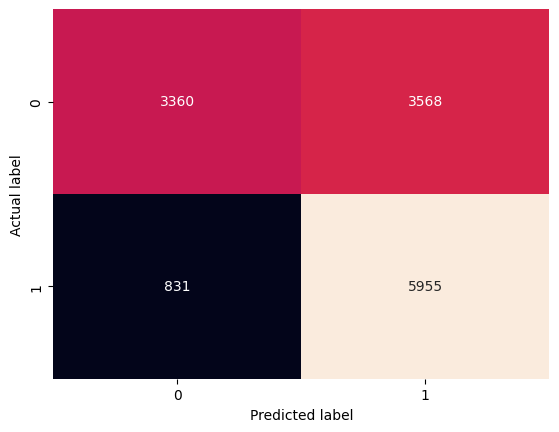

Tačnost klasifikacije iznosi 67.92%
Preciznost klasifikacije iznosi 62.53%
Senzitivnost klasifikacije iznosi 87.75%
Specifičnost klasifikacije iznosi 48.50%
Stopa lažno negativnih iznosti 12.25%


In [ ]:
# evaluacija klasifikatora pri novoizabranom pragu
best_th = 0.50
y_pred_th = (y_proba >= best_th).astype(int)

conf_mat = confusion_matrix(y_test, y_pred_th)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tačnost klasifikacije iznosi {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosi {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosi {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specifičnost klasifikacije iznosi {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

Na osnovu rezultata zaključeno je da dodatno pomeranje praga nakon ponderisanog učenja ne donosi značajno poboljšanje performansi, jer je sam model već optimizovan za smanjenje broja propuštenih slučajeva. Izabrani kompromis (tačnost oko 69% uz FNR < 15%) pokazao se kao najstabilniji i klinički najprihvatljiviji balans između senzitivnosti i tačnosti klasifikacije.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=25,
    class_weight={0:1,1:2},
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, y_proba_rf))

AUC: 0.8008763266002754


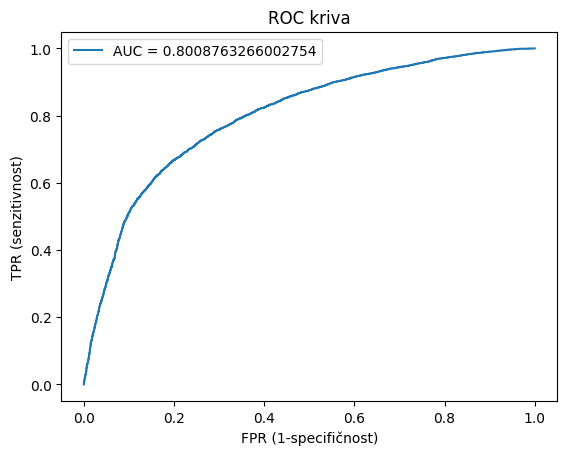

In [ ]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test,  y_proba_rf)
auc = metrics.roc_auc_score(y_test, y_proba_rf)
plt.plot(fpr,tpr,label="AUC = " + str(auc))
plt.legend()
plt.title("ROC kriva")
plt.xlabel("FPR (1-specifičnost)")
plt.ylabel("TPR (senzitivnost)")
plt.show()

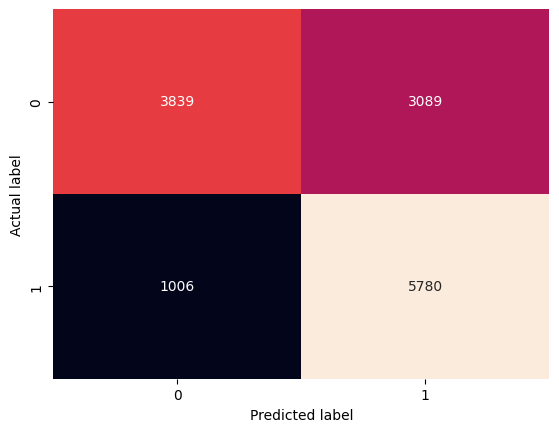

Tacnost klasifikacije iznosti 70.14%
Preciznost klasifikacije iznosti 65.17%
Senzitivnost klasifikacije iznosti 85.18%
Specificnost klasifikacije iznosti 55.41%
Stopa lažno negativnih iznosti 14.82%


In [ ]:
conf_mat = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tacnost klasifikacije iznosti {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosti {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosti {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specificnost klasifikacije iznosti {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

In [ ]:
y_proba_val = log.predict_proba(X_val)[:,1]
thresholds = np.arange(0.1, 0.8, 0.01)
best = []
for th in thresholds:
    y_pred_th = (y_proba_val >= th).astype(int)
    cm = confusion_matrix(y_val, y_pred_th)
    TN, FP, FN, TP = cm.ravel()
    fnr = FN / (FN + TP)
    tpr = TP / (TP + FN)
    acc = (TP + TN) / cm.sum()
    best.append((th, fnr, acc))

for th, fnr, acc in best:
    if fnr <= 0.15 and acc >= 0.6:
        print(f"th={th:.2f}  FNR={fnr:.2f}  acc={acc:.2f}")

th=0.38  FNR=0.05  acc=0.60
th=0.39  FNR=0.05  acc=0.61
th=0.40  FNR=0.05  acc=0.61
th=0.41  FNR=0.06  acc=0.62
th=0.42  FNR=0.06  acc=0.63
th=0.43  FNR=0.07  acc=0.63
th=0.44  FNR=0.07  acc=0.64
th=0.45  FNR=0.08  acc=0.64
th=0.46  FNR=0.09  acc=0.65
th=0.47  FNR=0.09  acc=0.66
th=0.48  FNR=0.10  acc=0.67
th=0.49  FNR=0.11  acc=0.67
th=0.50  FNR=0.12  acc=0.68
th=0.51  FNR=0.13  acc=0.69
th=0.52  FNR=0.14  acc=0.69


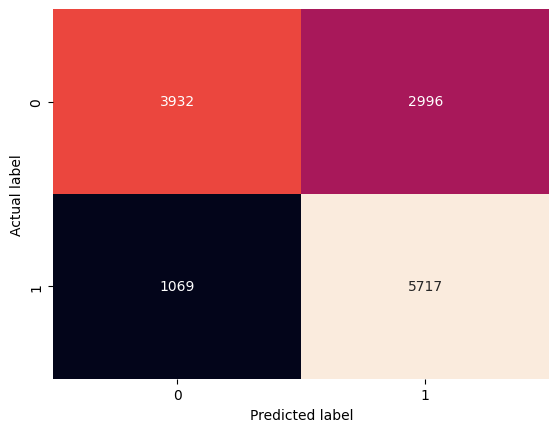

Tačnost klasifikacije iznosi 70.36%
Preciznost klasifikacije iznosi 65.61%
Senzitivnost klasifikacije iznosi 84.25%
Specifičnost klasifikacije iznosi 56.76%
Stopa lažno negativnih iznosti 15.75%


In [ ]:
# evaluacija klasifikatora pri novoizabranom pragu
best_th = 0.51
y_pred_th = (y_proba_rf >= best_th).astype(int)

conf_mat = confusion_matrix(y_test, y_pred_th)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tačnost klasifikacije iznosi {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosi {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosi {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specifičnost klasifikacije iznosi {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

KNN


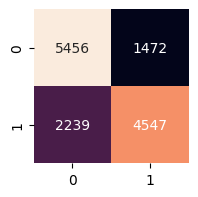

Tacnost klasifikacije iznosti 72.94%
Preciznost klasifikacije iznosti 75.54%
Senzitivnost klasifikacije iznosti 67.01%
Specificnost klasifikacije iznosti 78.75%
Stopa lažno negativnih iznosti 32.99%


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier as KNN

knn = KNN(n_neighbors=203)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

conf_mat = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(2,2))
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tacnost klasifikacije iznosti {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosti {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosti {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specificnost klasifikacije iznosti {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

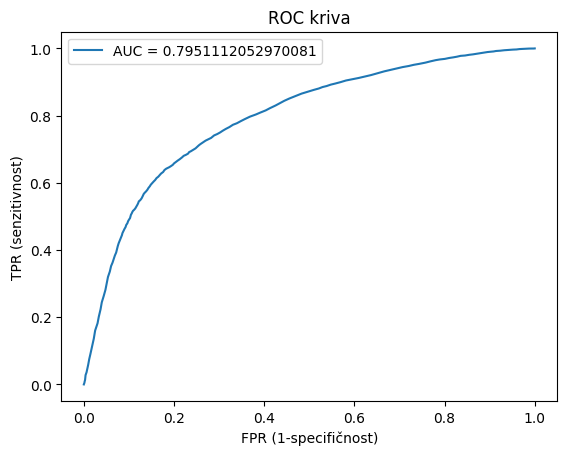

In [ ]:
from sklearn import metrics
y_proba_knn = knn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_proba_knn)
auc = metrics.roc_auc_score(y_test, y_proba_knn)
plt.plot(fpr,tpr,label="AUC = " + str(auc))
plt.legend()
plt.title("ROC kriva")
plt.xlabel("FPR (1-specifičnost)")
plt.ylabel("TPR (senzitivnost)")
plt.show()

In [ ]:
y_proba_val = knn.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.1, 0.6, 0.01)
best = []
for th in thresholds:
    y_pred_th = (y_proba_val >= th).astype(int)
    cm = confusion_matrix(y_val, y_pred_th)
    TN, FP, FN, TP = cm.ravel()
    fnr = FN / (FN + TP)
    tpr = TP / (TP + FN)
    acc = (TP + TN) / cm.sum()
    best.append((th, fnr, acc))

# ispiši one ispod 0.15 FNR
for th, fnr, acc in best:
    if fnr <= 0.15:
        print(f"th={th:.2f}  FNR={fnr:.2f}  acc={acc:.2f}")

th=0.10  FNR=0.00  acc=0.52
th=0.11  FNR=0.01  acc=0.53
th=0.12  FNR=0.01  acc=0.54
th=0.13  FNR=0.01  acc=0.54
th=0.14  FNR=0.01  acc=0.55
th=0.15  FNR=0.02  acc=0.56
th=0.16  FNR=0.02  acc=0.56
th=0.17  FNR=0.02  acc=0.57
th=0.18  FNR=0.03  acc=0.58
th=0.19  FNR=0.03  acc=0.59
th=0.20  FNR=0.03  acc=0.59
th=0.21  FNR=0.04  acc=0.60
th=0.22  FNR=0.05  acc=0.61
th=0.23  FNR=0.05  acc=0.62
th=0.24  FNR=0.06  acc=0.63
th=0.25  FNR=0.07  acc=0.64
th=0.26  FNR=0.09  acc=0.65
th=0.27  FNR=0.09  acc=0.66
th=0.28  FNR=0.10  acc=0.67
th=0.29  FNR=0.11  acc=0.67
th=0.30  FNR=0.12  acc=0.68
th=0.31  FNR=0.13  acc=0.68
th=0.32  FNR=0.14  acc=0.69
th=0.33  FNR=0.15  acc=0.69


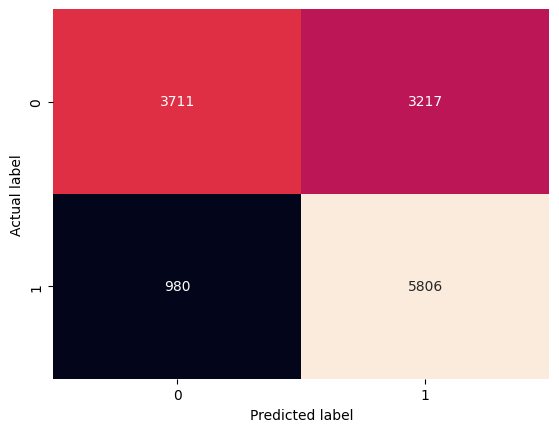

Tačnost klasifikacije iznosi 69.40%
Preciznost klasifikacije iznosi 64.35%
Senzitivnost klasifikacije iznosi 85.56%
Specifičnost klasifikacije iznosi 53.57%
Stopa lažno negativnih iznosti 14.44%


In [ ]:
# evaluacija klasifikatora pri novoizabranom pragu
best_th = 0.33
y_pred_th = (y_proba_knn >= best_th).astype(int)

conf_mat = confusion_matrix(y_test, y_pred_th)
plt.figure()
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tačnost klasifikacije iznosi {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosi {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosi {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specifičnost klasifikacije iznosi {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

NN

In [ ]:
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from keras import Sequential
from keras.layers import Input, Dense

model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))
#model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(1, activation='sigmoid')) # za 2 klase 1 izlaz
model.summary()

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_105 (Dense)               │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6894 - loss: 0.6756 - val_accuracy: 0.7285 - val_loss: 0.5614
Epoch 2/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7297 - loss: 0.5672 - val_accuracy: 0.7265 - val_loss: 0.5553
Epoch 3/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7299 - loss: 0.5612 - val_accuracy: 0.7269 - val_loss: 0.5565
Epoch 4/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7266 - loss: 0.5607 - val_accuracy: 0.7285 - val_loss: 0.5522
Epoch 5/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7246 - loss: 0.5623 - val_accuracy: 0.7287 - val_loss: 0.5516
Epoch 6/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7334 - loss: 0.5527 - val_accuracy: 0.7289 - val_loss: 0.5497
Epoch 7/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7330 - loss: 0.5561 - val_accuracy: 0.7302 - val_loss: 0.5527
Epoch 8/80
686/686 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7308 - loss: 0.5539 - val_accuracy: 0.

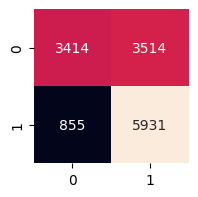

Tacnost klasifikacije iznosti 68.14%
Preciznost klasifikacije iznosti 62.80%
Senzitivnost klasifikacije iznosti 87.40%
Specificnost klasifikacije iznosti 49.28%
Stopa lažno negativnih iznosti 12.60%


In [ ]:
max_epochs = 80
es = EarlyStopping(monitor='val_loss', mode='min', patience=20, verbose=1)

model.compile('adam', loss = 'binary_crossentropy', metrics=['accuracy'])
history = model.fit(x=X_train, y=y_train, epochs=max_epochs, batch_size=64, shuffle=True, validation_data=(X_val, y_val), callbacks=[es], verbose = 1)
#history = model.fit(x=Xtrening, y=Ytrening, epochs=max_epochs, batch_size=64, shuffle=True, validation_data=(Xval, Yval), verbose=1)

#y_pred = model.predict(X_test, verbose=0)
y_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_proba >= 0.33).astype(int)

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(2,2))
sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
plt.show()

TP = conf_mat[1, 1]
FP = conf_mat[0, 1]
TN = conf_mat[0, 0]
FN = conf_mat[1, 0]
tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
print(f'Tacnost klasifikacije iznosti {tacnost:.2f}%')
preciznost = 100*TP/(TP + FP)
print(f'Preciznost klasifikacije iznosti {preciznost:.2f}%')
senzitivnost = 100*TP/(TP + FN)
print(f'Senzitivnost klasifikacije iznosti {senzitivnost:.2f}%')
specificnost = 100*TN/(TN + FP)
print(f'Specificnost klasifikacije iznosti {specificnost:.2f}%')
FNR = 100*FN/(FN + TP)
print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')

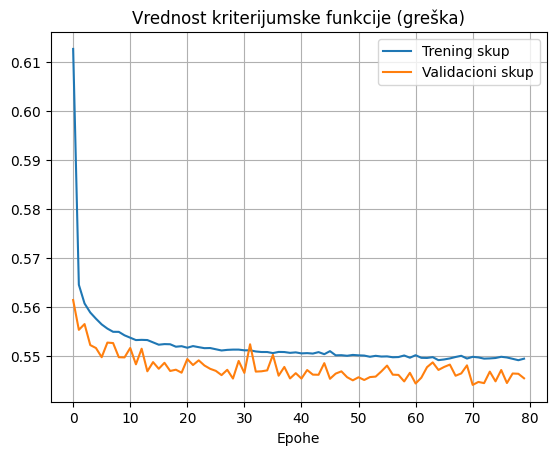

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Trening skup')
plt.plot(history.history['val_loss'], label='Validacioni skup')
plt.title("Vrednost kriterijumske funkcije (greška)")
plt.legend()
#plt.xlim(0, 100)
plt.xlabel("Epohe")
plt.grid()
plt.show()

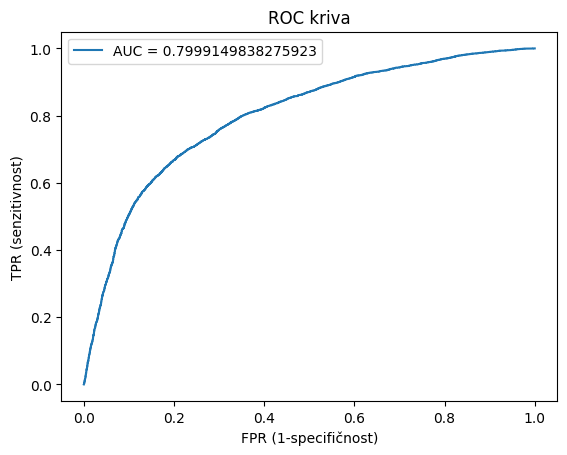

In [ ]:
from sklearn import metrics
y_proba = model.predict(X_test, verbose=0).ravel()
fpr, tpr, _ = metrics.roc_curve(y_test,  y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)
plt.plot(fpr,tpr,label="AUC = " + str(auc))
plt.legend()
plt.title("ROC kriva")
plt.xlabel("FPR (1-specifičnost)")
plt.ylabel("TPR (senzitivnost)")
plt.show()

In [ ]:
y_proba = model.predict(X_val, verbose=0).ravel()
thresholds = np.arange(0.1, 0.6, 0.01)
best = []
for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)
    cm = confusion_matrix(y_val, y_pred_th)
    TN, FP, FN, TP = cm.ravel()
    fnr = FN / (FN + TP)
    tpr = TP / (TP + FN)
    acc = (TP + TN) / cm.sum()
    best.append((th, fnr, acc))

for th, fnr, acc in best:
    if fnr <= 0.15 and acc >= 0.6:
        print(f"th={th:.2f}  FNR={fnr:.2f}  acc={acc:.2f}")

th=0.22  FNR=0.04  acc=0.60
th=0.23  FNR=0.04  acc=0.61
th=0.24  FNR=0.05  acc=0.62
th=0.25  FNR=0.05  acc=0.62
th=0.26  FNR=0.06  acc=0.63
th=0.27  FNR=0.07  acc=0.64
th=0.28  FNR=0.08  acc=0.65
th=0.29  FNR=0.08  acc=0.66
th=0.30  FNR=0.09  acc=0.66
th=0.31  FNR=0.10  acc=0.67
th=0.32  FNR=0.11  acc=0.68
th=0.33  FNR=0.12  acc=0.68
th=0.34  FNR=0.13  acc=0.69
th=0.35  FNR=0.14  acc=0.70


In [ ]:
# import lightgbm as lgb

# params = {
#     "objective": "binary",
#     "metric": "auc",
#     "learning_rate": 0.05,
#     "num_leaves": 31,
#     "max_depth": -1,
#     "feature_fraction": 0.8,
#     "bagging_fraction": 0.8,
#     "bagging_freq": 1,
#     "lambda_l2": 1.0,
#     "scale_pos_weight": 2,   # prilagodi prema odnosu klasa
#     "verbose": -1,
# }

# dtrain = lgb.Dataset(X_train, label=y_train)
# dval   = lgb.Dataset(X_val,   label=y_val)

# gbm = lgb.train(params, dtrain, num_boost_round=2000,
#                 valid_sets=[dval], valid_names=["val"])

# # verovatnoće i izbor praga po FNR ≤ 0.15
# p = gbm.predict(X_val, num_iteration=gbm.best_iteration)
# best = []
# for th in np.linspace(0.1, 0.6, 51):
#     yhat = (p >= th).astype(int)
#     tn, fp, fn, tp = confusion_matrix(y_val, yhat).ravel()
#     fnr = fn/(fn+tp)
#     acc = (tp+tn)/(tp+tn+fp+fn)
#     best.append((th, fnr, acc))
# best_th, _, _ = sorted([b for b in best if b[1] <= 0.15],
#                        key=lambda x: (-x[2], x[1], x[0]))[0]


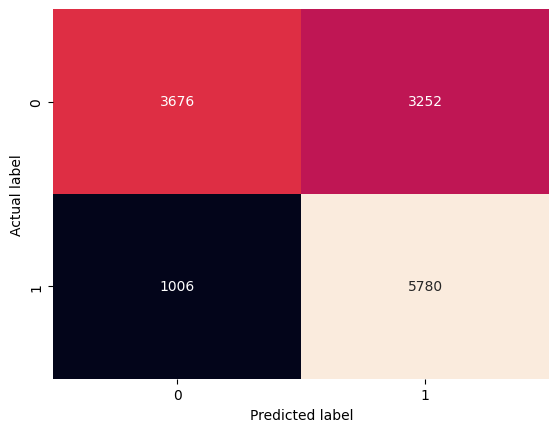

Tačnost klasifikacije iznosi 68.95%
Preciznost klasifikacije iznosi 63.99%
Senzitivnost klasifikacije iznosi 85.18%
Specifičnost klasifikacije iznosi 53.06%
Stopa lažno negativnih iznosti 14.82%


In [ ]:
# yhat = (p >= best_th).astype(int)

# conf_mat = confusion_matrix(y_test, yhat)
# plt.figure()
# sns.heatmap(conf_mat, annot=True, fmt='g', cbar=False)
# plt.ylabel('Actual label')
# plt.xlabel('Predicted label')
# plt.show()

# TP = conf_mat[1, 1]
# FP = conf_mat[0, 1]
# TN = conf_mat[0, 0]
# FN = conf_mat[1, 0]
# tacnost = 100*np.trace(conf_mat)/np.sum(conf_mat)
# print(f'Tačnost klasifikacije iznosi {tacnost:.2f}%')
# preciznost = 100*TP/(TP + FP)
# print(f'Preciznost klasifikacije iznosi {preciznost:.2f}%')
# senzitivnost = 100*TP/(TP + FN)
# print(f'Senzitivnost klasifikacije iznosi {senzitivnost:.2f}%')
# specificnost = 100*TN/(TN + FP)
# print(f'Specifičnost klasifikacije iznosi {specificnost:.2f}%')
# FNR = 100*FN/(FN + TP)
# print(f'Stopa lažno negativnih iznosti {FNR:.2f}%')